<a href="https://colab.research.google.com/github/gleo1973/tp-laboratorio-mcag-1c2026/blob/main/Laboratorio_TP_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*Universidad de Buenos Aires · Facultad de Ciencias Económicas  
Tecnicatura Universitaria en Gestión y Análisis de Datos en Organizaciones*

# **Trabajo Práctico Grupal**
Exploración, análisis y presentación de datos reales asistida por IA  

## Análisis y comparación de los equipos de la Copa Mundial de Fútbol 2026.

*Por Leonardo Gomez, Fernando Morichetti y Carla Garibotti.*

---




# Análisis Exploratorio de datos

## Importacion de Librerias

En este bloque se importan las principales librerias de Python que serán utilizadas a lo largo del trabajo para el procesamiento, análisis y visualización de los datos. 

Estas herramientas conforman el entorno de trabajo principal del proyecto y permiten desarrollar tanto el análisis exploratorio inicial como la aplicación de conceptos cuantitativos vistos en la materia.

In [22]:
import pandas as pd #para manejo de archivos de datos
import numpy as np #para hacer operaciones matemáticas
import matplotlib.pyplot as plt #para hacer gráficos
import seaborn as sns #para hacer gráficos

import sympy as sp
import os #yo borraria esto....
from scipy.optimize import curve_fit #libreria para encontrar la curva que mejor se ajusta a los datos
from scipy.stats import pearsonr #libreria para calcular el coeficiente de correlación de Pearson

# Carpeta para exportar gráficos al informe
os.makedirs("imagenes", exist_ok=True) #yo borraria esto....

## Carga de datasets principales

En este bloque se importan las primeras fuentes de datos que formarán la base del análisis. Ambos datasets serán utilizados de manera complementaria para construir una estructura unificada de información sobre selecciones nacionales y países participantes.

El primer dataset contiene información histórica y estadística relacionada con las selecciones nacionales que participan de la Copa Mundial 2026. Esta base constituye la fuente principal del análisis ya que nos otorga las variables principales para el análisis sobre el rendimiento de las distintas selecciones.

El segundo dataset corresponde al listado oficial de asociaciones miembro de la FIFA y sus respectivos códigos de identificación. Esta información será utilizada como tabla auxiliar para normalizar nombres de países y facilitar la integración entre datasets provenientes de distintas fuentes.


In [23]:
# Ver fuente en archivo /datos/fuentes.md

df_paises = pd.read_csv("datos/raw/paises.csv")

### Exploracion inicial

Consultamos la dimensión del dataset, con el objetivo de conocer la cantidad de filas y columnas disponibles en la base de datos. La cantidad de filas debe  contener 48 filas, correspondientes a los 48 equipos

In [24]:
df_paises.shape

(48, 24)

Consultamos las columnas presentes en el dataset con el objetivo de identificar las variables disponibles para el análisis.

In [25]:
df_paises.columns

Index(['version', 'team', 'continent', 'is_host', 'goals_scored_last_4y',
       'goals_received_last_4y', 'wins_last_4y', 'losses_last_4y',
       'draws_last_4y', 'world_cup_titles_before',
       'squad_total_market_value_eur', 'fifa_rank_pre_tournament',
       'fifa_points_pre_tournament', 'squad_avg_age',
       'world_cup_participations_before', 'groups_passed_before',
       'round16_before', 'quarterfinals_before', 'semifinals_before',
       'finals_before', 'winner', 'finalist', 'semi_finalist',
       'quarter_finalist'],
      dtype='object')

Visualizamos las primeras filas. Como tiene muchas columnas, vamos a transponer la tabla con el objetivo de facilitar la lectura de los campos y sus respectivos valores.

In [26]:
df_paises.head(8).T

,0,1,2,3,4,5,6,7
version,2026,2026,2026,2026,2026,2026,2026,2026
team,France,Spain,Argentina,England,Portugal,Brazil,Netherlands,Morocco
continent,Europe,Europe,South America,Europe,Europe,South America,Europe,Africa
is_host,0,0,0,0,0,0,0,0
goals_scored_last_4y,85,104,80,82,98,58,92,100
goals_received_last_4y,32,32,14,23,31,39,41,18
wins_last_4y,25,29,30,26,26,15,21,37
losses_last_4y,6,2,4,6,5,10,8,2
draws_last_4y,7,8,3,7,7,10,9,9
world_cup_titles_before,2,1,3,1,0,5,0,0


Vemos que la tabla tiene distintos valores:  
- version: refiere a la versión del torneo FIFA sobre el cuál trata la información.  
- team: identifica al equipo/plantel nacional.  
- continent: de qué continente es el equipo.  
- is_host: si es el anfitrión del torneo en el año indicado en "version".  
  
Y luego hay datos históricos sobre el desempeño de cada plantel:  
- goals_scored_last_4y: goles marcados en los últimos 4 años.  
- goals_received_last_4y: goles recibimos en los últimos 4 años.  
- wins_last_4y: victorias en los últimos 4 años.  
- losses_last_4y: pérdidas en los últimos 4 años.  
- draws_last_4y: empates en los últimos 4 años.  
- world_cup_titles_before: veces que el plantel ha ganado el torneo.  
- squad_total_market_value_eur: valor de mercado del equipo en euros.  
- fifa_rank_pre_tournament: posición en el ranking FIFA antes del comienzo del torneo.  
- fifa_points_pre_tournament: puntaje FIFA antes del comienzo del torneo.  
- squad_avg_age: edad promedio de los jugadores.  
- world_cup_participations_before: cuántas veces ha participado en la copa del Mundo.  
- groups_passed_before: cuántas veces ha superado la fase de grupos históricamente.  
- round16_before: cuántas veces ha llegado al top 16 históricamente.  
- quarterfinals_before: cuántos cuartos de finales ha jugado el plantel históricamente.  
- semifinals_before: cuántas semifinales ha jugado el plantel históricamente.  
- finals_before: cuántas finales ha jugado el plantel históricamente.  

Finalmente hay 4 columnas que se completarían luego de finalizado el torneo:  
- winner: si fue el ganador del torneo.  
- finalist: si fue finalista en el torneo.  
- semi_finalist: si fue semifinalista en el torneo.  
- quarter_finalist: si llegó a cuartos de finales en el torneo.  

Contamos los valores vacíos de la tabla.

In [27]:
df_paises.isna().sum()

version                             0
team                                0
continent                           0
is_host                             0
goals_scored_last_4y                0
goals_received_last_4y              0
wins_last_4y                        0
losses_last_4y                      0
draws_last_4y                       0
world_cup_titles_before             0
squad_total_market_value_eur        0
fifa_rank_pre_tournament            0
fifa_points_pre_tournament          0
squad_avg_age                       0
world_cup_participations_before     0
groups_passed_before                0
round16_before                      0
quarterfinals_before                0
semifinals_before                   0
finals_before                       0
winner                             48
finalist                           48
semi_finalist                      48
quarter_finalist                   48
dtype: int64

Como las últimas cuatro columnas son para completar luego del torneo, es esperable que estén vacías.  

Revisamos si hay valores duplicados.

In [28]:
print(f"Cantidad de filas duplicadas: {df_paises.duplicated().sum()}")

Cantidad de filas duplicadas: 0


Revisamos el listado de países. Hay países que son nombrados de formas distintas en distintas bases de datos y como usaremos esta columna para combinar las tablas más adelante, necesitamos saber cómo están escritos.

In [29]:
print(df_paises["team"].unique())

['France' 'Spain' 'Argentina' 'England' 'Portugal' 'Brazil' 'Netherlands'
 'Morocco' 'Belgium' 'Germany' 'Croatia' 'Colombia' 'Senegal' 'Mexico'
 'United States' 'Uruguay' 'Japan' 'Switzerland' 'Iran' 'Turkey' 'Ecuador'
 'Austria' 'South Korea' 'Australia' 'Algeria' 'Egypt' 'Canada' 'Norway'
 'Panama' 'Ivory Coast' 'Sweden' 'Paraguay' 'Czech Republic' 'Scotland'
 'Tunisia' 'DR Congo' 'Uzbekistan' 'Qatar' 'Iraq' 'South Africa'
 'Saudi Arabia' 'Jordan' 'Bosnia and Herzegovina' 'Cape Verde' 'Ghana'
 'Cura?o' 'Haiti' 'New Zealand']


Vemos que un valor (Curaçao) quedó mal escrito, así que vamos a corregir ese valor puntual y luego vamos a revisar que ya no queden valores con "?".

In [30]:
df_paises['team'] = df_paises['team'].replace('Cura?o', 'Curaçao')
df_paises[df_paises['team'].str.contains(r'\?', na=False)]

,version,team,continent,is_host,goals_scored_last_4y,goals_received_last_4y,wins_last_4y,losses_last_4y,draws_last_4y,world_cup_titles_before,...,world_cup_participations_before,groups_passed_before,round16_before,quarterfinals_before,semifinals_before,finals_before,winner,finalist,semi_finalist,quarter_finalist


Importamos otro dataset para sumar los datos estadísticos (poblacionales y demográficos).

In [31]:
# Fuente: https://simplemaps.com/data/countries


df_info_paises = pd.read_csv("datos/raw/country_info.csv")

Revisamos cuántas filas y columnas tiene. Debería tener más de 250 filas, ya que contiene información sobre todos los países del mundo.

In [32]:
df_info_paises.shape

(253, 18)

También para estaa revisamos si hay valaores duplicados:

In [33]:
print(f"Cantidad de filas duplicadas: {df_paises.duplicated().sum()}")

Cantidad de filas duplicadas: 0


Revisamos qué tipo de información tiene esta tabla:

In [34]:
df_info_paises.head(3).T

,0,1,2
country,China,India,United States
demonym,Chinese,Indian,American
id,CN,IN,US
iso2,CN,IN,US
tld,.cn,.in,.us
currency,Chinese Yuan,Indian Rupee,United States Dollar
population,1413142846.0,1399179585.0,339665118.0
density,147.2,425.6,34.5
area,9596960.0,3287263.0,9833517.0
gdp,17963170.0,3465541.0,25744100.0


Vemos que la tabla cuenta con la siguiente información:
- country: nombre del país.  
- demonym: gentilicio.  
- id: código del país.  
- iso2: código ISO3166-2 (de 2 letras) que identifica cada país.
- tld: código de sitios web del país.  
- currency: moneda oficial.  
- population: población.  
- density: densidad poblacional.  
- area: extensión geográfica del país.  
- gdp: producto bruto interno (PBI).  
- median_age: mediana de edad.  
- language: idioma oficial.  
- website: web oficial.  
- calling_code: código telefónico del país.  
- driving_side: dirección de manejo vehicular.  
- continent: continente.  
- un_member: si es miembro de la ONU.  
- religion: religión principal.  

Revisamos si cuenta con valores vacíos.

In [35]:
df_info_paises.isna().sum()

country          0
demonym          9
id               1
iso2             4
tld              7
currency         8
population      14
density         16
area            11
gdp             47
median_age      28
language         8
website         13
calling_code    15
driving_side     1
continent        3
un_member        0
religion         6
dtype: int64

Vemos que tiene valores vacíos. No nos preocupa *a priori* porque no es nuestra base principal, solo necesitamos que en el cruce con la base de equipos no queden lugares vacíos, pero saber que hay valores faaltantes nos da la pauta de que tenemos que tener particular cuidado cuando hagamos el cruce.

Hago un merge con los nombres de países para traer la información estadística.  


In [36]:
df_paises_merge = df_paises.merge(
    df_info_paises,
    left_on='team',
    right_on='country',
    how='left'
)
df_paises_merge.head(3).T

,0,1,2
version,2026,2026,2026
team,France,Spain,Argentina
continent_x,Europe,Europe,South America
is_host,0,0,0
goals_scored_last_4y,85,104,80
goals_received_last_4y,32,32,14
wins_last_4y,25,29,30
losses_last_4y,6,2,4
draws_last_4y,7,8,3
world_cup_titles_before,2,1,3


Revisamos si quedaron valores vacíos.

In [37]:
df_paises_merge.isna().sum()

version                             0
team                                0
continent_x                         0
is_host                             0
goals_scored_last_4y                0
goals_received_last_4y              0
wins_last_4y                        0
losses_last_4y                      0
draws_last_4y                       0
world_cup_titles_before             0
squad_total_market_value_eur        0
fifa_rank_pre_tournament            0
fifa_points_pre_tournament          0
squad_avg_age                       0
world_cup_participations_before     0
groups_passed_before                0
round16_before                      0
quarterfinals_before                0
semifinals_before                   0
finals_before                       0
winner                             48
finalist                           48
semi_finalist                      48
quarter_finalist                   48
country                             3
demonym                             3
id          

Vemos que quedaron 3 países que no cruzaron. Revisamos cuáles.

In [38]:
sin_cruzar = df_paises_merge[df_paises_merge['country'].isna()][['team']]
print(sin_cruzar)

        team
3    England
33  Scotland
35  DR Congo


Vamos a revisar cómo llaman a DR Congo en este dataset para poder modificar el valor. 

In [21]:
print(df_info_paises["country"].unique())

['China' 'India' 'United States' 'Indonesia' 'Pakistan' 'Nigeria' 'Brazil'
 'Bangladesh' 'Russia' 'Mexico' 'Japan' 'Ethiopia' 'Philippines'
 'Democratic Republic of the Congo' 'Egypt' 'Vietnam' 'Iran' 'Germany'
 'Turkey' 'Thailand' 'France' 'United Kingdom' 'Tanzania' 'Italy'
 'South Africa' 'Myanmar' 'Kenya' 'South Korea' 'Colombia' 'Sudan'
 'Uganda' 'Spain' 'Argentina' 'Algeria' 'Ukraine' 'Iraq' 'Afghanistan'
 'Canada' 'Poland' 'Morocco' 'Angola' 'Saudi Arabia' 'Malaysia' 'Ghana'
 'Mozambique' 'Peru' 'Yemen' 'Uzbekistan' 'Nepal' 'Venezuela' 'Cameroon'
 'Ivory Coast' 'Madagascar' 'Australia' 'North Korea' 'Niger' 'Taiwan'
 'Sri Lanka' 'Syria' 'Burkina Faso' 'Mali' 'Malawi' 'Zambia' 'Kazakhstan'
 'Chile' 'Chad' 'Senegal' 'Romania' 'Guatemala' 'Ecuador' 'Netherlands'
 'Cambodia' 'Zimbabwe' 'Benin' 'Guinea' 'Rwanda' 'Burundi' 'Somalia'
 'Bolivia' 'South Sudan' 'Tunisia' 'Belgium' 'Haiti' 'Jordan' 'Cuba'
 'Dominican Republic' 'Czech Republic' 'Sweden' 'Greece' 'Azerbaijan'
 'Portugal' 'Un

In [40]:
df_info_paises['country'] = df_info_paises['country'].replace('Democratic Republic of the Congo', 'DR Congo')

Con eso corregimos el nombre de DR Congo. Escocia e Inglaterra presentan un problema especial porque son dos equipos de un mismo país.  
Como la información no numérica es igual, lo que vamos a hacver es copiar para ambos la información de Reino Unido. A continuación copio la fila de Reino Unido dos veces y le cambio el valor en "country" por Inglaterra y Escocia para que puedan cruzar esos dos equipos.
> ⚠️ *Nota* : Tanto Escocia como Inglaterra tendrán ambos la información de Reino Unido entero así que si sumamos los valores numéricos tendremos que eliminar duplicados.  


In [42]:
fila_uk = df_info_paises[df_info_paises['country'] == 'United Kingdom'].copy()

fila_england = fila_uk.copy()
fila_england['country'] = 'England'

fila_scotland = fila_uk.copy()
fila_scotland['country'] = 'Scotland'

df_info_paises = pd.concat([df_info_paises, fila_england, fila_scotland], ignore_index=True)


Volvemos a intentar el merge y vemos si quedaron valores vacíos.

In [43]:
df_paises_merge = df_paises.merge(
    df_info_paises,
    left_on='team',
    right_on='country',
    how='left'
)
df_paises_merge.isna().sum()

version                             0
team                                0
continent_x                         0
is_host                             0
goals_scored_last_4y                0
goals_received_last_4y              0
wins_last_4y                        0
losses_last_4y                      0
draws_last_4y                       0
world_cup_titles_before             0
squad_total_market_value_eur        0
fifa_rank_pre_tournament            0
fifa_points_pre_tournament          0
squad_avg_age                       0
world_cup_participations_before     0
groups_passed_before                0
round16_before                      0
quarterfinals_before                0
semifinals_before                   0
finals_before                       0
winner                             48
finalist                           48
semi_finalist                      48
quarter_finalist                   48
country                             0
demonym                             0
id          

Vemos que cruzaron todos pero quedaron algunos valores vacíos: "GDP" (PBI, en español) y "calling_code" (código tele´fonico). El segundo no forma parte del análisis pero PBI sí, así que revisamos qué valor está faltando.

In [44]:
print(df_paises_merge[df_paises_merge['gdp'].isna()][['team']])


       team
45  Curaçao


Vemos que el PBI que falta es el de Curaçao así que buscamos y completamos este valor de forma manual consultando el Banco Mundial.  
Según la fuente [NY.GDP.MKTP.CD](https://data.worldbank.org/indicator/NY.GDP.MKTP.CD), el PBI de Curaçao en 2022 fue aproximadamente **3.561 millones de USD**, que es la unidad utilizada en el dataset `country_info.csv`.

In [45]:
# Imputación manual del PBI de Curaçao
# Fuente: Banco Mundial - NY.GDP.MKTP.CD (2022)
# Unidad: millones de USD (igual que el resto del dataset country_info.csv)

df_paises_merge.loc[df_paises_merge["team"] == "Curaçao", "gdp"] = 3561.0


Revisamos que ya no haya valores vacíos para PBI.

In [46]:
print(df_paises_merge[df_paises_merge['gdp'].isna()][['team']])

Empty DataFrame
Columns: [team]
Index: []


Teniendo ya toda la información que nos interesa, filtramos para que nos queden las columnas que nos interesan para el análisis.

In [48]:
df_paises_f = df_paises_merge[[
     "team", 
     "continent_x", 
     "squad_total_market_value_eur", 
     "fifa_points_pre_tournament", 
     "squad_avg_age",
     "population", 
     "density",
     "area", 
     "gdp", 
     "median_age", 
     "language", 
     "religion"]].copy()


Armamos un diccionario para renombrar las columnas

In [49]:

columnas = {"team":"pais",
            "continent_x":"continente",
            "squad_total_market_value_eur":"valor_en_euros",
            "fifa_points_pre_tournament":"puntos_FIFA",
            "squad_avg_age":"edad_promedio_equipo",
            "population" : "poblacion",
            "density" : "densidad",
            "area" : "superficie",
            "gdp" : "pbi",
            "median_age" : "edad_mediana_pais",
            "language" : "idioma",
            }
df_paises_f.rename(columns=columnas,inplace=True)

Generamos una columna de PBI per cápita dividiendo los valores de PBI por la población.

In [50]:
df_paises_f["pbi_per_capita"] = df_paises_f["pbi"] / df_paises_f["poblacion"]

Vamos a buscar si hay relación en términos matemáticos entre las variables numéricas. A esos fines, primero revisamos los tipos de variables que tenemos.

In [51]:
df_paises_f.dtypes

pais                     object
continente               object
valor_en_euros            int64
puntos_FIFA             float64
edad_promedio_equipo    float64
poblacion               float64
densidad                float64
superficie              float64
pbi                     float64
edad_mediana_pais       float64
idioma                   object
religion                 object
pbi_per_capita          float64
dtype: object

Creamos un mapa de calor para visualizar la correlación entre las variables.  
Selecionamos solo las columnas con variables numéricas de interés.

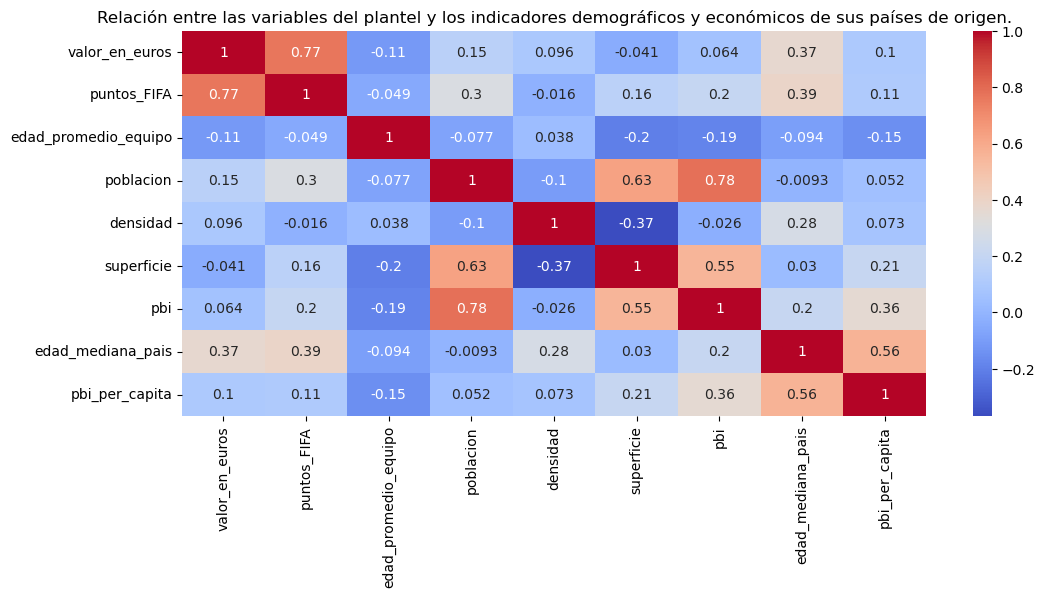

In [52]:
numerico_df = df_paises_f.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 5))
sns.heatmap(numerico_df.corr(), annot=True, cmap='coolwarm')
plt.title("Relación entre las variables del plantel y los indicadores demográficos y económicos de sus países de origen.")
plt.savefig("imagenes/heatmap-relacion-variables-numericas.png")

plt.show()


Conclusión: Hay una correlación fuerte entre el puntaje FIFA y el valor estimado del equipo, lo cual es lógico.  
Estos valores, sin embargo, no tienen ninguna correlación con los estadísticos del país que consideramos.  
Vamos a hacer entonces un scatterplot para ver qué relación tienen estas dos variables.  


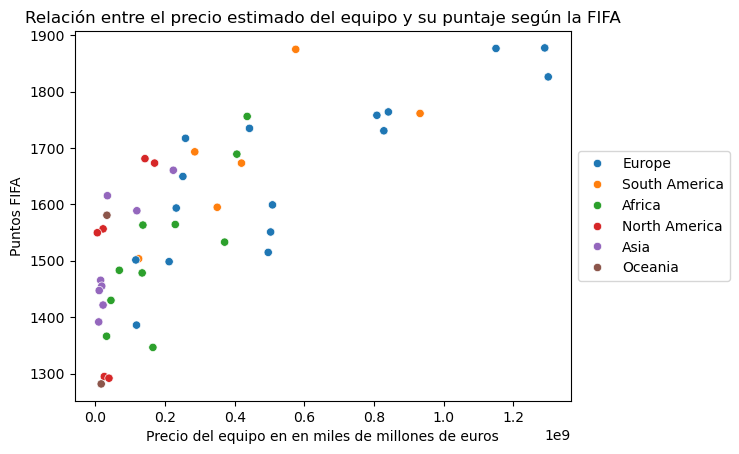

In [53]:
sns.scatterplot(
    data=df_paises_f, 
    x='valor_en_euros', 
    y="puntos_FIFA",
    hue='continente', #el color lo da el continente
    legend="full" #pone la leyenda
)
plt.title("Relación entre el precio estimado del equipo y su puntaje según la FIFA")
plt.xlabel('Precio del equipo en en miles de millones de euros')
plt.ylabel("Puntos FIFA")
plt.legend(bbox_to_anchor=(1, 0.5), loc='center left')
plt.savefig("imagenes/scattermap-puntajefifa-precioestimado.png")

plt.show()

Vemos que hay un equipo que parece lejano a la curva, aislamos los primeros 6 equipos para ver de qué país se trata:

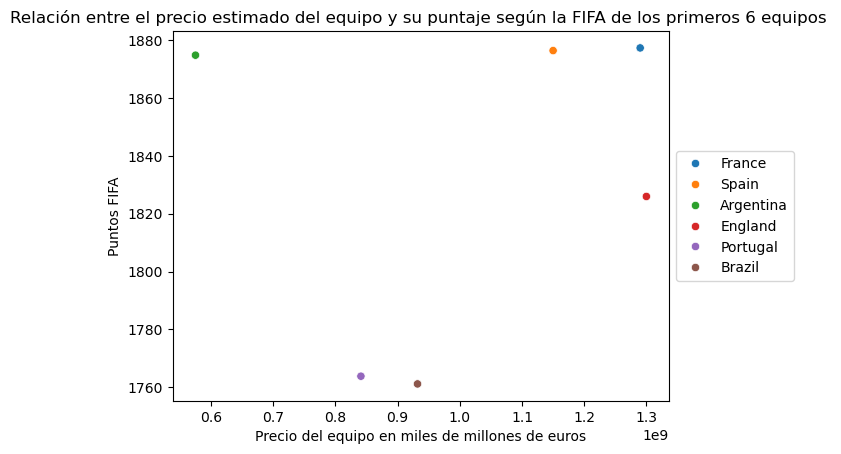

In [54]:
sns.scatterplot(
    data=df_paises_f.head(6), #detalle de los primeros 6 paises
    x='valor_en_euros', 
    y="puntos_FIFA",
    hue="pais", #el color lo da el pais
    legend="full" #pone la leyenda
)
plt.title("Relación entre el precio estimado del equipo y su puntaje según la FIFA de los primeros 6 equipos ")
plt.xlabel('Precio del equipo en miles de millones de euros')
plt.ylabel("Puntos FIFA")
plt.legend(bbox_to_anchor=(1, 0.5), loc='center left')
plt.savefig("imagenes/scattermap-puntajefifa-precioestimado-primeros6.png")

plt.show()

Conclusión: El país que parecía excepcional, por tener un precio de mercado muy inferior a lo que su puntaje indica es Argentina.  
Esto indica que Argentina tiene un desempeño mucho mejor que lo que se esperaría por el valor de sus jugadores. Múltiples motivos podrían explicar esta excepcionalidad: por ejemplo, un gran desempeño del equipo técnico, generando un equipo con sinergias que superan el valor agregado de sus jugadores.  

## Análisis por variables categóricas
### Continente:

Para ver si el continente de origen afecta el desempeño, generamos un boxplot que muestre la distribución de puntos FIFA por continente.

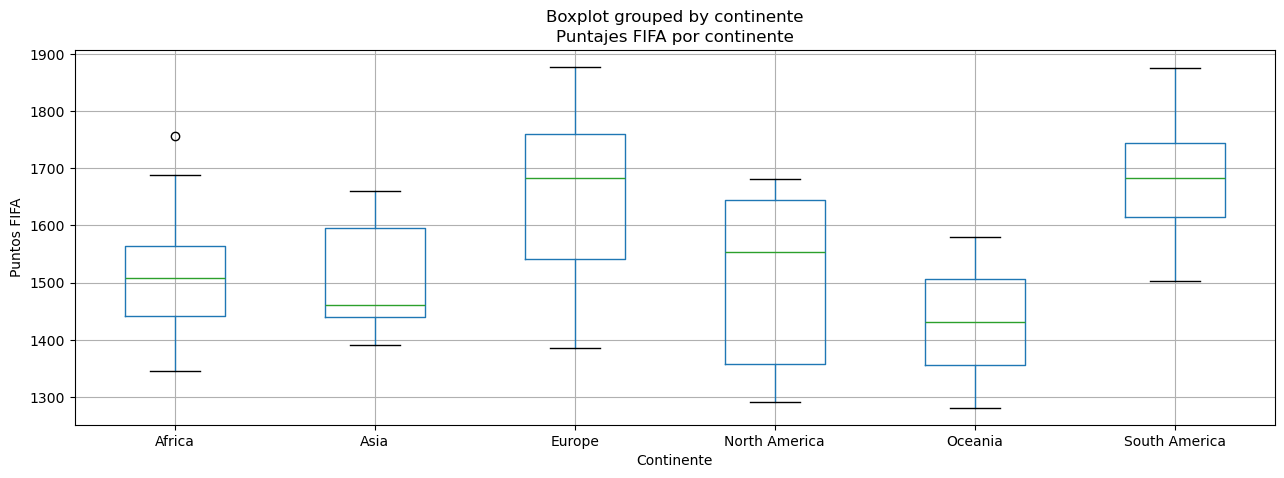

In [55]:
df_paises_f.boxplot('puntos_FIFA', 'continente', figsize=(15, 5), grid=True)
plt.title("Puntajes FIFA por continente")
plt.xlabel("Continente")
plt.ylabel("Puntos FIFA")
plt.savefig("imagenes/boxplot-puntajefifa-continente.png")

plt.show()

Conclusión: El continente de origen del país sí parece ser un indicador importante del puntaje del equipo. América del Sur y Europa tienen puntajes superiores a los del resto. Posibles explicaciones: la competencia intra continental obliga a subir el nivel.

### Religión
Revisamos primero cómo están distribuidas las religiones con un gráfico de torta.

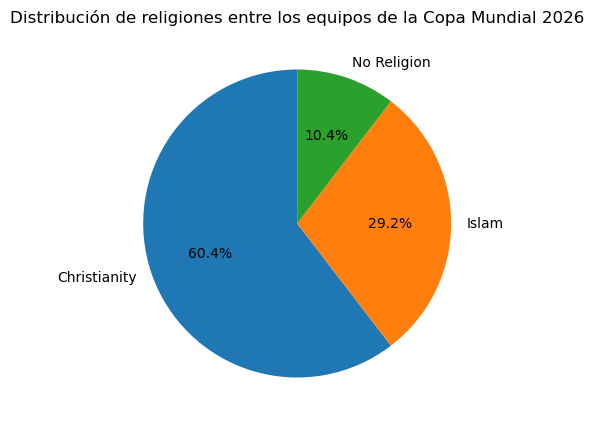

In [56]:
religion_count = df_paises_f["religion"].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(
    religion_count,
    labels=religion_count.index,   
    autopct="%1.1f%%",
    startangle=90,
)
plt.title("Distribución de religiones entre los equipos de la Copa Mundial 2026")
plt.savefig("imagenes/piechart-religiones.png")

plt.show()

Conclusión: Curiosamente, los países que participan del torneo son mayoritariamente cristianos, islámicos o no tienen religión principal. No hay países identificados como mayoritariamente budistas, hindúes o judíos.

Hacemos un boxplot para comparar los rendimientos de las distintas religiones. 

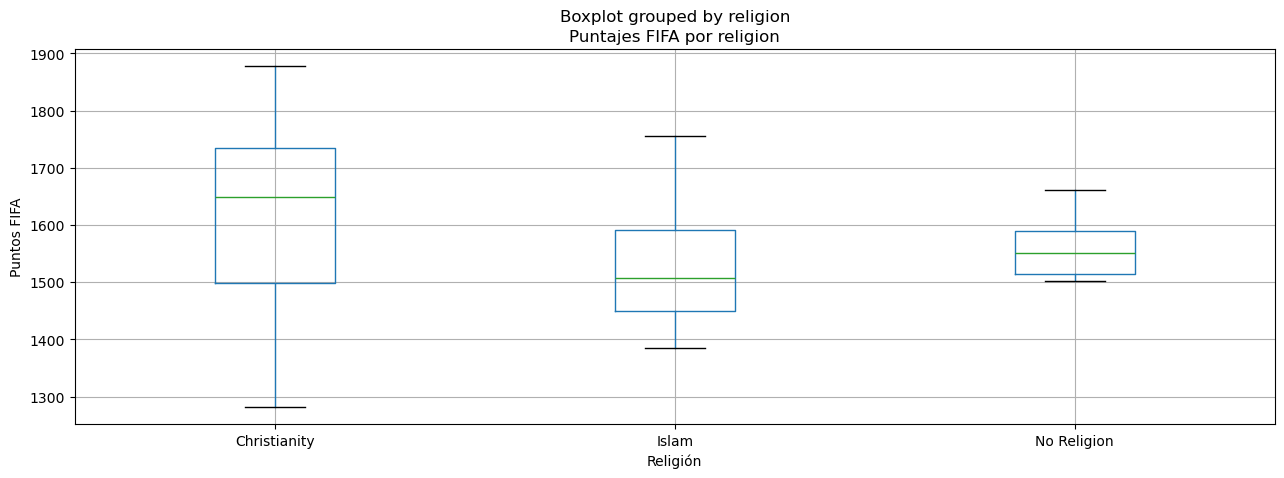

In [57]:
df_paises_f.boxplot('puntos_FIFA', 'religion', figsize=(15, 5), grid=True, )
plt.title("Puntajes FIFA por religion")
plt.xlabel("Religión")
plt.ylabel("Puntos FIFA")
plt.savefig("imagenes/boxplot-puntajefifa-religion.png")

plt.show()

Los países cristianos son mayoría, así que es esperable que tengan un spread mucho mayor. Sin embargo, se ve que la mediana de los países cristianos está más alta. Podemos pensar que seguramente esta categoría esté relacionada con la de continentes y haya una variable demográfica o cultural que explica ambas.

### Idioma
Hacemos un boxplot para ver si se ve una diferencia por idioma también.

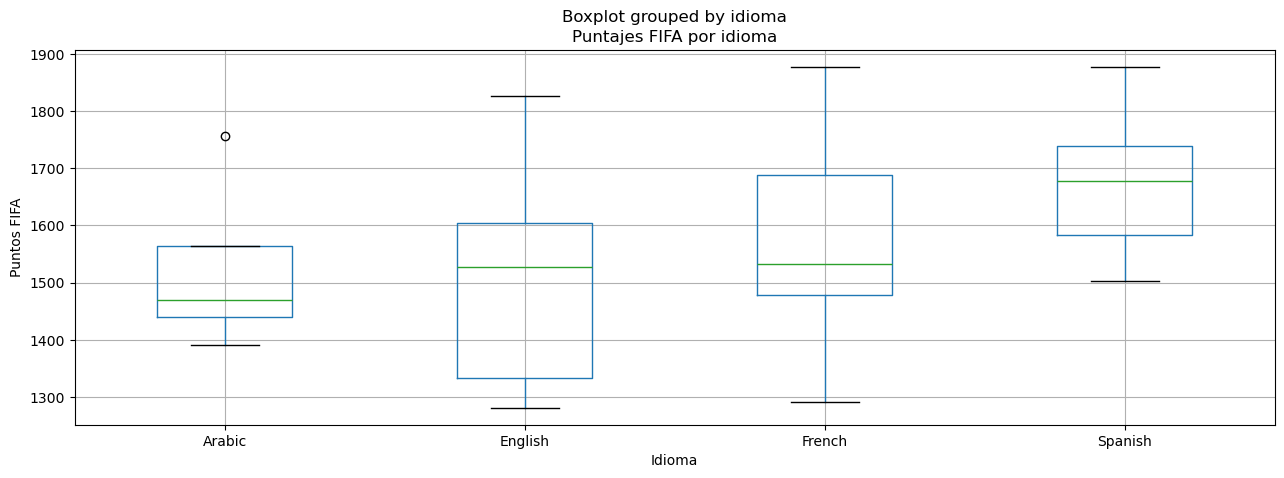

In [58]:
#uso IA para filtrar y solo tomar los idiomas que tengan más de 3 paises, para que el gráfico sea legible.
#prompt: "Quiero hacer un boxplot de puntajes FIFA por idioma, pero hay muchos idiomas con solo 1 o 2 países, lo que hace que el gráfico sea difícil de leer. 
#Filtrar el dataframe para quedarme solo con los idiomas que tengan más de 3 países."

df_paises_f_2 = df_paises_f.groupby('idioma').filter(lambda x: len(x) > 3)

df_paises_f_2.boxplot('puntos_FIFA', 'idioma', figsize=(15, 5), grid=True)
plt.title("Puntajes FIFA por idioma")
plt.xlabel("Idioma")
plt.ylabel("Puntos FIFA")
plt.savefig("imagenes/boxplot-puntajefifa-idioma.png")

plt.show()

Conclusión: parece haber una tendencia notable en los países de habla hispana a tener un puntaje más elevado en promedio que en otros países. El resultado no es sorprendente considerando que el continente de Sudamérica también tiene puntaje más alto que la media; seguramente haya una explicación cultural que explica ambos fenómenos.

# Análisis de la relación entre puntos FIFA y valor del equipo
El análisis exploratorio mostró una correlación fuerte solamente entre el valor de mercado del plantel y el puntaje FIFA (r = 0,77). El siguiente paso es modelar la forma que toma esa relación.

El objetivo es analizar cómo es la curva que une el puntaje FIFA y el valor estimado del equipo. Visualmente parece ser una curva cóncava hacia abajo. Para evaluar y encontrar la curva que mejor se ajusta, utilizamos Claude (Anthropic) para evaluar de entre cuatro modelos funcionales (lineal, logarítmico, potencia y cuadrático) cuál se ajusta mejor a los datos.

>Prompt utilizado: 
> "Evaluá modelos lineal, logarítmico, potencia y cuadrático para ajustar la > relación entre valor de plantel (x) y puntaje FIFA (y). Compará por R² y calculá las derivadas analíticas con sympy."

## Modelos a evaluar

Probamos los siguientes **cuatro modelos funcionales** sobre los mismos datos y evaluamos su ajuste a los datos comparando sus coeficiente de determinación R²:  

| Modelo | Función |
|---|---|
| Lineal | $$f(x) = mx + b$$ |
| Logarítmico | $$f(x) = a \cdot ln(x) + b$$ |
| Potencia | $$f(x) = axᵇ$$ |
| Cuadrático | $$f(x) = ax² + bx + c$$ |

Una vez identificado el mejor modelo, se calcula su **derivada analítica** con `sympy`. La derivada f'(x) mide el rendimiento marginal: cuántos puntos FIFA adicionales se obtienen por cada €100M extra invertidos en el plantel, según 
el nivel de inversión actual del equipo.

── Comparación de modelos por R² ────────────────────────────────
     Modelo     R²
 Cuadrático 0.6292
     Lineal 0.5902
   Potencia 0.5681
Logarítmico 0.5517

── Derivadas (tasa de cambio marginal) ──────────────────────────
  Lineal         : f'(x) = 348.714938386931
  Logarítmico    : f'(x) = 79.2172749013864/x
  Potencia       : f'(x) = 91.6061944630969/x**0.947501391815863
  Cuadrático     : f'(x) = 612.271873143349 - 470.739774227379*x

── Puntos FIFA marginales por cada €100M adicionales ────────────
  Valor (€B)          Lineal     Logarítmico        Potencia      Cuadrático
         0.1            34.9            79.2            81.2            56.5
         0.3            34.9            26.4            28.7            47.1
         0.6            34.9            13.2            14.9            33.0
         1.0            34.9             7.9             9.2            14.2
         1.3            34.9             6.1             7.1             0.0

── Vértice del modelo 

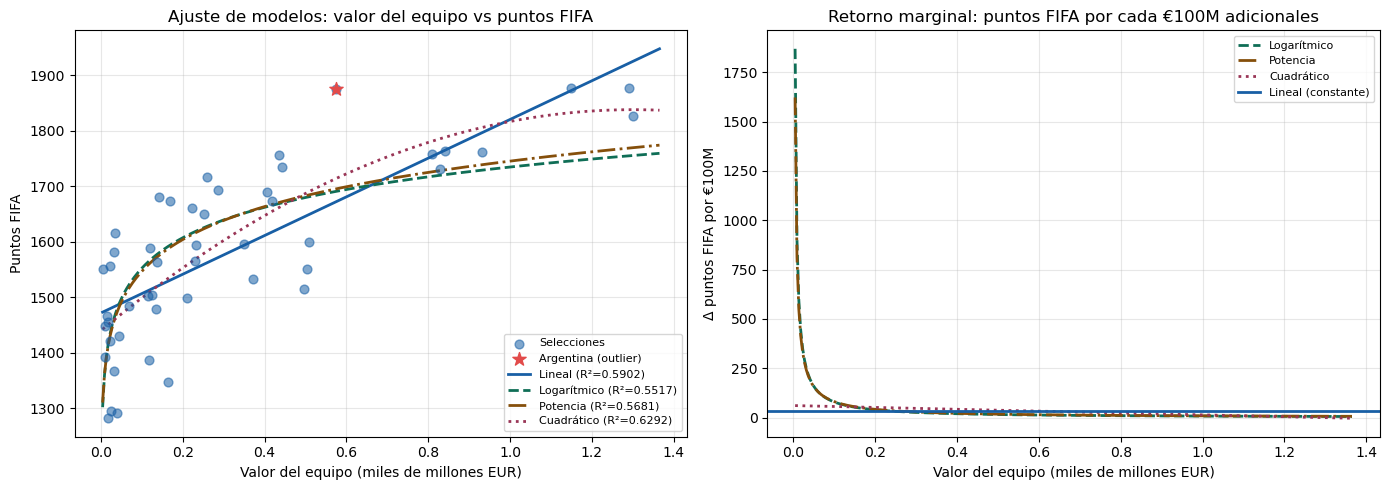

In [59]:
# Ajuste de curvas: relación entre valor del equipo y puntaje FIFA
# Aplicación del concepto de la materia: derivadas e integrales (Sección 3.5)
#

# ── 1. Definición de modelos ──────────────────────────────────────────────────

def modelo_lineal(x, m, b):
    """f(x) = m·x + b"""
    return m * x + b

def modelo_logaritmico(x, a, b):
    """f(x) = a·ln(x) + b"""
    return a * np.log(x) + b

def modelo_potencia(x, a, b):
    """f(x) = a · x^b"""
    return a * np.power(x, b)

def modelo_cuadratico(x, a, b, c):
    """f(x) = a·x² + b·x + c"""
    return a * x**2 + b * x + c


# ── 2. Preparación de datos ───────────────────────────────────────────────────

# ajuste: normalizamos x dividiéndolo por 1.000.000.000
# El motivo: los valores originales están en euros (ej: 575.000.000).
# Al elevarlos al cuadrado en el modelo cuadrático, se obtienen números del
# orden de 10^17, lo que hace que curve_fit no converja correctamente.
# Expresar x en miles de millones (ej: 0.575) resuelve el problema
# sin perder información — solo cambia la escala.

x_raw = df_paises_f["valor_en_euros"].values
y     = df_paises_f["puntos_FIFA"].values
x     = x_raw / 1_000_000_000          # ← x ahora está en miles de millones de EUR


# ── 3. Ajuste de los cuatro modelos ──────────────────────────────────────────

params_lin,  _ = curve_fit(modelo_lineal,      x, y)
params_log,  _ = curve_fit(modelo_logaritmico, x, y)
params_pow,  _ = curve_fit(modelo_potencia,    x, y, p0=[1500, 0.3], maxfev=5000)
params_cuad, _ = curve_fit(modelo_cuadratico,  x, y)


# ── 4. R² para cada modelo ────────────────────────────────────────────────────

def r_cuadrado(y_real, y_pred):
    """Coeficiente de determinación R²."""
    ss_res = np.sum((y_real - y_pred) ** 2)
    ss_tot = np.sum((y_real - np.mean(y_real)) ** 2)
    return 1 - ss_res / ss_tot

modelos = {
    "Lineal":       (modelo_lineal,      params_lin),
    "Logarítmico":  (modelo_logaritmico, params_log),
    "Potencia":     (modelo_potencia,    params_pow),
    "Cuadrático":   (modelo_cuadratico,  params_cuad),
}

resultados = []
for nombre, (fn, params) in modelos.items():
    y_pred = fn(x, *params)
    r2     = r_cuadrado(y, y_pred)
    resultados.append({"Modelo": nombre, "R²": round(r2, 4)})

df_resultados = pd.DataFrame(resultados).sort_values("R²", ascending=False)
print("── Comparación de modelos por R² ────────────────────────────────")
print(df_resultados.to_string(index=False))


# ── 5. Derivadas analíticas con sympy ─────────────────────────────────────────

xv = sp.Symbol("x", positive=True)

f_lin  = params_lin[0]  * xv + params_lin[1]
f_log  = params_log[0]  * sp.log(xv) + params_log[1]
f_pow  = params_pow[0]  * xv ** params_pow[1]
f_cuad = params_cuad[0] * xv**2 + params_cuad[1] * xv + params_cuad[2]

derivadas = {
    "Lineal":      sp.diff(f_lin,  xv),
    "Logarítmico": sp.diff(f_log,  xv),
    "Potencia":    sp.diff(f_pow,  xv),
    "Cuadrático":  sp.diff(f_cuad, xv),
}

print("\n── Derivadas (tasa de cambio marginal) ──────────────────────────")
for nombre, deriv in derivadas.items():
    print(f"  {nombre:15s}: f'(x) = {sp.simplify(deriv)}")


# ── 6. Tabla de rendimiento marginal ─────────────────────────────────────────
# Interpretación: cuántos puntos FIFA se ganan por cada €100M adicionales
# según el nivel de inversión actual del equipo (x en miles de millones)

valores_ref = [0.1, 0.3, 0.6, 1.0, 1.3]   # en miles de millones de EUR

print("\n── Puntos FIFA marginales por cada €100M adicionales ────────────")
header = f"{'Valor (€B)':>12}" + "".join(f"  {k:>14}" for k in derivadas)
print(header)
for val in valores_ref:
    fila = f"{val:>12.1f}"
    for nombre, deriv in derivadas.items():
        tasa = float(deriv.evalf(subs={xv: val})) * 0.1   # per €100M
        fila += f"  {tasa:>14.1f}"
    print(fila)


# ── 7. Vértice del modelo cuadrático ─────────────────────────────────────────
# x_vertice = -b / (2a) → punto de máximo rendimiento según el modelo

a_c, b_c, c_c = params_cuad
x_vertice = -b_c / (2 * a_c)
y_vertice = modelo_cuadratico(x_vertice, a_c, b_c, c_c)

print(f"\n── Vértice del modelo cuadrático ────────────────────────────────")
print(f"  Inversión óptima : €{x_vertice:.3f} miles de millones")
print(f"  Puntaje máximo   : {y_vertice:.1f} puntos FIFA")
print(f"  Interpretación   : por encima de este valor, invertir más deja")
print(f"                     de traducirse en mejora de puntaje FIFA.")


# ── 8. Gráfico ────────────────────────────────────────────────────────────────

x_curve = np.linspace(x.min() * 0.8, x.max() * 1.05, 300)

colores = {
    "Lineal":      "#185FA5",
    "Logarítmico": "#0F6E56",
    "Potencia":    "#854F0B",
    "Cuadrático":  "#993556",
}
estilos = {
    "Lineal":      "-",
    "Logarítmico": "--",
    "Potencia":    "-.",
    "Cuadrático":  ":",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: scatter + curvas ajustadas
ax = axes[0]
ax.scatter(x, y, color="#185FA5", alpha=0.55, s=40, zorder=3, label="Selecciones")

arg_mask = df_paises_f["pais"] == "Argentina"
ax.scatter(
    df_paises_f.loc[arg_mask, "valor_en_euros"] / 1_000_000_000,
    df_paises_f.loc[arg_mask, "puntos_FIFA"],
    color="#E24B4A", s=100, zorder=4, marker="*", label="Argentina (outlier)"
)

for nombre, (fn, params) in modelos.items():
    r2 = df_resultados.loc[df_resultados["Modelo"] == nombre, "R²"].values[0]
    ax.plot(x_curve, fn(x_curve, *params),
            color=colores[nombre], ls=estilos[nombre], lw=2,
            label=f"{nombre} (R²={r2})")

ax.set_title("Ajuste de modelos: valor del equipo vs puntos FIFA")
ax.set_xlabel("Valor del equipo (miles de millones EUR)")
ax.set_ylabel("Puntos FIFA")
ax.legend(fontsize=8, loc="lower right")
ax.grid(True, alpha=0.3)

# Panel derecho: derivadas — rendimiento marginal
ax2 = axes[1]
for nombre, deriv in derivadas.items():
    if nombre == "Lineal":
        continue
    y_deriv = [float(deriv.evalf(subs={xv: v})) * 0.1 for v in x_curve]
    ax2.plot(x_curve, y_deriv,
             color=colores[nombre], ls=estilos[nombre], lw=2, label=nombre)

# La derivada lineal es una constante simbólica de sympy, no un float de Python.
# float(sympy_expr) a veces funciona pero falla si la expresión no está evaluada.
# .evalf() fuerza la evaluación numérica antes de la conversión — siempre seguro.

derivada_lineal_valor = float(derivadas["Lineal"].evalf()) * 0.1
ax2.axhline(
    derivada_lineal_valor,
    color=colores["Lineal"], ls="-", lw=2, label="Lineal (constante)"
)

ax2.set_title("Retorno marginal: puntos FIFA por cada €100M adicionales")
ax2.set_xlabel("Valor del equipo (miles de millones EUR)")
ax2.set_ylabel("Δ puntos FIFA por €100M")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()

# plt.show() cierra la figura activa en Colab, así que guardar después
# produce una imagen en blanco. El orden correcto es siempre savefig → show.
plt.savefig("imagenes/ajuste_modelos.png", dpi=150, bbox_inches="tight")

plt.show()

### Interpretación de los resultados

**Comparación de modelos**  
El modelo cuadrático obtuvo el mayor R² (0,629), seguido por el lineal (0,590), 
el de potencia (0,568) y el logarítmico (0,552). Las diferencias entre modelos 
son moderadas, pero el cuadrático es el único que captura un elemento 
económicamente relevante: el **coeficiente a es negativo**, lo que implica que 
la parábola se abre hacia abajo y el rendimiento de la inversión es decreciente.

**La derivada como herramienta de interpretación**  
En el modelo cuadrático, vemos que f'(x) = 2a·x + b es una función 
decreciente de x: los equipos con planteles de bajo valor obtienen muchos puntos 
por cada €100M extra, mientras que los equipos con planteles ya costosos obtienen 
cada vez menos.

La tabla de rendimiento marginal muestra esta diferencia con precisión: un equipo 
con un plantel de €0,1B gana aproximadamente el triple de puntos por cada 
€100M adicionales que un equipo con un plantel de €1,0B. Esto es consistente 
con la teoría económica de **rendimientos marginales decrecientes**.

**Conclusión de la sección**  
El análisis confirma que la relación entre inversión en plantel y puntaje FIFA 
no es lineal. Existe un punto de máximo rendimiento — el vértice de la parábola — 
más allá del cual invertir más deja de mejorar el puntaje. Ese punto y sus 
implicancias se analizan en detalle en el gráfico siguiente.

## Modelo cuadrático: análisis del ajuste y sus implicancias

Entre los cuatro modelos evaluados, el **cuadrático** obtuvo el mayor coeficiente 
de determinación (R² = 0.629), lo que indica que explica el 62,9% de la varianza 
del puntaje FIFA a partir del valor del plantel.

A continuación se presenta el gráfico de cierre del análisis, que integra tres 
elementos en una sola visualización:

1. La curva ajustada con su ecuación
2. El **vértice** de la parábola — el punto de inversión óptima donde f'(x) = 0
3. Los **residuos** de los casos más destacados: qué tan lejos está cada equipo 
   de lo que el modelo predice

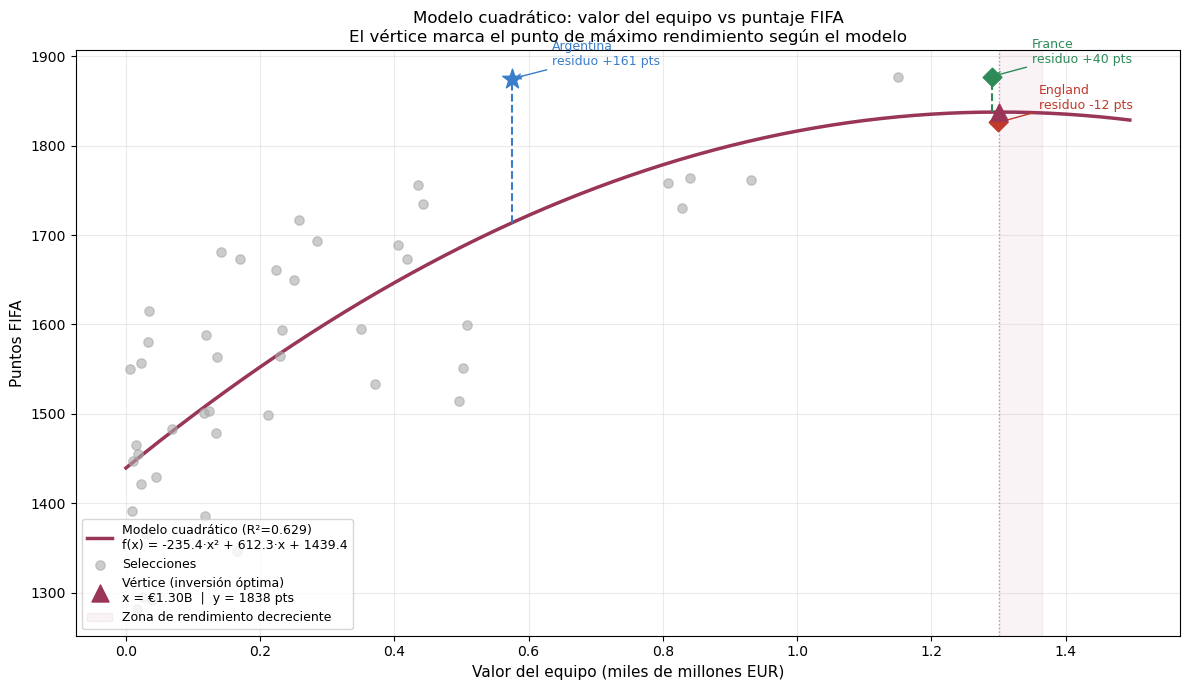

── Equipos con mayor residuo positivo (rinden más de lo esperado) ──
         País  Valor (€B)  Puntos FIFA  Predicción    Residuo
    Argentina     0.57500      1874.81 1713.682052 161.127948
       Mexico     0.14210      1681.03 1521.696042 159.333958
         Iran     0.03425      1615.30 1460.139102 155.160898
United States     0.16970      1673.13 1536.569228 136.560772
      Croatia     0.25850      1717.07 1581.989228 135.080772


In [60]:
# ─────────────────────────────────────────────────────────────────────────────
# Modelo cuadrático con vértice, residuos y casos destacados
# Este gráfico es la conclusión visual de la Sección 3.5 del TP.
# ─────────────────────────────────────────────────────────────────────────────

# ── 1. Parámetros del modelo cuadrático  ───────────────
a_c, b_c, c_c = params_cuad

x_vertice = -b_c / (2 * a_c)
y_vertice = modelo_cuadratico(x_vertice, a_c, b_c, c_c)

# ── 2. Residuos ───────────────────────────────────────────────────────────────
df_paises_f["x_b"]     = df_paises_f["valor_en_euros"] / 1_000_000_000
df_paises_f["y_pred"]  = modelo_cuadratico(df_paises_f["x_b"], a_c, b_c, c_c)
df_paises_f["residuo"] = df_paises_f["puntos_FIFA"] - df_paises_f["y_pred"]

# ── 3. Gráfico ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

# Curva del modelo cuadrático
x_curve = np.linspace(0, x_vertice * 1.15, 300)
ax.plot(
    x_curve,
    modelo_cuadratico(x_curve, a_c, b_c, c_c),
    color="#993556", lw=2.5, zorder=2,
    label=f"Modelo cuadrático (R²=0.629)\nf(x) = {a_c:.1f}·x² + {b_c:.1f}·x + {c_c:.1f}"
)

# Todos los equipos (puntos grises)
ax.scatter(
    df_paises_f["x_b"], df_paises_f["puntos_FIFA"],
    color="#AAAAAA", alpha=0.6, s=45, zorder=3, label="Selecciones"
)

# Casos destacados: Argentina, Francia, Inglaterra
casos = {
    "Argentina": {"color": "#3A7DC9", "marker": "*", "size": 220},
    "France":    {"color": "#2E8B57", "marker": "D", "size": 90},
    "England":   {"color": "#C0392B", "marker": "D", "size": 90},
}
for pais, estilo in casos.items():
    fila = df_paises_f[df_paises_f["pais"] == pais].iloc[0]
    ax.scatter(
        fila["x_b"], fila["puntos_FIFA"],
        color=estilo["color"], marker=estilo["marker"],
        s=estilo["size"], zorder=5
    )
    # Línea de residuo (distancia al modelo)
    ax.plot(
        [fila["x_b"], fila["x_b"]],
        [fila["y_pred"], fila["puntos_FIFA"]],
        color=estilo["color"], lw=1.5, ls="--", zorder=4
    )
    # Etiqueta con el residuo
    signo = "+" if fila["residuo"] > 0 else ""
    ax.annotate(
        f"{pais}\nresiduo {signo}{fila['residuo']:.0f} pts",
        xy=(fila["x_b"], fila["puntos_FIFA"]),
        xytext=(fila["x_b"] + 0.06, fila["puntos_FIFA"] + 15),
        fontsize=9, color=estilo["color"],
        arrowprops=dict(arrowstyle="->", color=estilo["color"], lw=1)
    )

# Vértice
ax.scatter(
    x_vertice, y_vertice,
    color="#993556", marker="^", s=150, zorder=5,
    label=f"Vértice (inversión óptima)\nx = €{x_vertice:.2f}B  |  y = {y_vertice:.0f} pts"
)
ax.axvline(x_vertice, color="#993556", lw=1, ls=":", alpha=0.5)

# Zona de rendimientos decrecientes
ax.axvspan(
    x_vertice, df_paises_f["x_b"].max() * 1.05,
    alpha=0.06, color="#993556",
    label="Zona de rendimiento decreciente"
)

ax.set_title(
    "Modelo cuadrático: valor del equipo vs puntaje FIFA\n"
    "El vértice marca el punto de máximo rendimiento según el modelo",
    fontsize=12
)
ax.set_xlabel("Valor del equipo (miles de millones EUR)", fontsize=11)
ax.set_ylabel("Puntos FIFA", fontsize=11)
ax.legend(fontsize=9, loc="lower left")
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig("imagenes/modelo_cuadratico_vertice.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 4. Tabla de residuos destacados ───────────────────────────────────────────
print("── Equipos con mayor residuo positivo (rinden más de lo esperado) ──")
print(df_paises_f[["pais", "x_b", "puntos_FIFA", "y_pred", "residuo"]]
      .sort_values("residuo", ascending=False)
      .head(5)
      .rename(columns={
          "pais":        "País",
          "x_b":         "Valor (€B)",
          "puntos_FIFA": "Puntos FIFA",
          "y_pred":      "Predicción",
          "residuo":     "Residuo"
      })
      .to_string(index=False))

### Interpretación de los resultados

**El vértice: inversión óptima**  
El modelo cuadrático alcanza su máximo en **x ≈ €1,30 miles de millones**, con un 
puntaje predicho de **1.837 puntos FIFA**. Esto significa que, según el modelo, 
ese es el nivel de inversión a partir del cual gastar más en el plantel deja de 
traducirse en mejoras de puntaje. Francia (€1,29B) e Inglaterra (€1,30B) se ubican 
prácticamente encima de ese punto — lo que sugiere que ambas selecciones operan 
en el límite de la eficiencia de inversión según este modelo.

**El caso Argentina: la anomalía cuantificada**  
Argentina presenta el mayor residuo positivo del dataset: sus **1.874 puntos FIFA** 
superan en **+161 puntos** la predicción del modelo para un plantel de €0,575B. 
En términos concretos, Argentina rinde como si su plantel valiera casi el doble. 
Este resultado es consistente con factores no capturados por el valor de mercado: 
cohesión táctica, continuidad del cuerpo técnico y el efecto del título obtenido 
en Qatar 2022.

**La zona de rendimiento decreciente**  
El área sombreada a la derecha del vértice representa equipos cuya inversión supera 
el óptimo del modelo. Para estos equipos, el modelo predice que incrementar aún más 
el gasto no genera mejoras — e incluso comienza a asociarse con puntajes menores, 
lo que puede reflejar que los equipos con planteles muy costosos no siempre logran 
traducir esa inversión en resultados deportivos colectivos.

**Limitación del modelo**  
Un coeficiente R² de 0.629 indica un ajuste moderado: el 37,1% de la varianza 
queda sin explicar. Esto es esperable dado que el fútbol de selecciones depende 
de variables que el valor de mercado no captura, como el sistema de juego, 
la experiencia en torneos y la fortaleza de la competencia intraconfederal.

## Síntesis matemática: ecuación, derivada y vértice

**La ecuación del modelo ganador: $$f(x) = ax² + bx + c$$**
$$f(x)   = -235.37x² + 612.27x + 1439.44$$
El coeficiente negativo del término cuadrático (a < 0) es el hallazgo clave del 
ajuste: la parábola se abre hacia abajo, lo que implica que la relación entre 
inversión en plantel y puntaje FIFA tiene un límite natural. Los puntos crecen 
al invertir más, pero a una tasa que se desacelera progresivamente hasta 
revertirse pasado el vértice.

**La derivada: $$f'(x) = 2ax + b$$**  
$$f'(x)  = -470.74·x + 612.27$$
En el modelo cuadrático la derivada es una función decreciente de x. Esto formaliza el concepto de rendimientos 
marginales decrecientes: para equipos con bajo gasto, cada €100M adicionales 
generan muchos puntos FIFA; para equipos con alto gasto, la misma inversión 
produce progresivamente menos. La tabla de rendimiento marginal de la sección 
anterior cuantifica esta diferencia con precisión.

**La segunda derivada: $$f''(x) = 2a$$**
$$f''(x) ≈ −471 (constante)$$
La segunda derivada del modelo cuadrático es un número constante, igual a
2 veces el coeficiente cuadrático ajustado. Su signo negativo confirma que
la parábola es cóncava hacia abajo en todo su dominio. 

**El vértice como umbral de eficiencia**  
El vértice de la parábola representa el nivel de inversión donde f'(x) = 0 y está ubicado en 
$$x = -b/(2a) ≈ €1,30B$$
Es el punto de máximo rendimiento según el modelo.
Francia (€1,29B) e Inglaterra (€1,30B) se ubican prácticamente sobre ese punto, 
lo que sugiere que las selecciones europeas de élite operan en el límite de la 
eficiencia de inversión — o incluso lo han superado.

**Argentina: los factores no monetarios como ventaja competitiva**  
El residuo positivo de Argentina (+161 puntos) es el mayor del dataset y 
constituye la anomalía más significativa del análisis. Su plantel, valorado en 
€0,575B, la sitúa por debajo del vértice, pero sus puntos FIFA superan con creces 
la predicción del modelo. Esto sugiere que factores no capturados por el valor de 
mercado — cohesión táctica, continuidad del cuerpo técnico, experiencia de campeón 
vigente — pueden compensar significativamente la menor inversión en plantel y 
representan una ventaja competitiva real e independiente del gasto.

── Modelo cuadrático: análisis diferencial completo ─────────────────
  f(x)   = -235.37·x² + 612.27·x + 1439.44
  f'(x)  = -470.74·x + 612.27
  f''(x) = -470.74

  Valor numérico de f''(x): -470.74  (constante en todo el dominio)
  Signo: negativo → concavidad hacia abajo

── Vértice (f'(x) = 0) ──────────────────────────────────────────────
  x* = -b/(2a) = €1.301B  →  puntaje máximo = 1837.6 pts FIFA
  Como f''(x) = -470.7 < 0, el vértice es un MÁXIMO (no un mínimo).


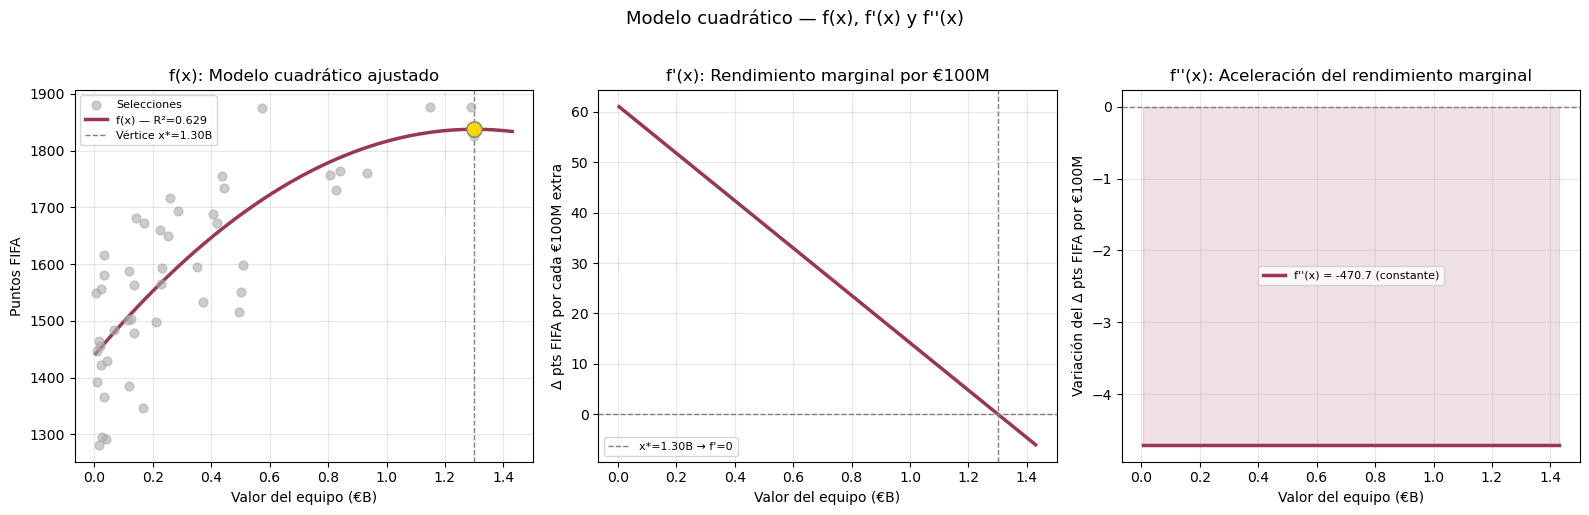

In [61]:
# ── Segunda derivada del modelo cuadrático (modelo de mejor ajuste, R²=0.629) ──
#
# ⚠️ Asistencia de IA: se utilizó Claude (Anthropic) para calcular la segunda
#    derivada analítica con sympy e interpretar su significado económico.
#    Prompt: "Calculá la segunda derivada del modelo cuadrático con sympy.
#    Interpretá el signo de f''(x) en términos de rendimientos marginales."
# ──────────────────────────────────────────────────────────────────────────────

# ── 1. Función simbólica y derivadas del modelo cuadrático ───────────────────
# f(x)   = a·x² + b·x + c
# f'(x)  = 2a·x + b      (primera derivada, ya calculada en la sección anterior)
# f''(x) = 2a             (segunda derivada — constante)

f_cuad       = params_cuad[0] * xv**2 + params_cuad[1] * xv + params_cuad[2]
deriv_cuad   = sp.diff(f_cuad, xv)          # primera derivada
seg_deriv_cuad = sp.diff(deriv_cuad, xv)    # segunda derivada

a_c, b_c, c_c = params_cuad

print("── Modelo cuadrático: análisis diferencial completo ─────────────────")
print(f"  f(x)   = {round(a_c, 2)}·x² + {round(b_c, 2)}·x + {round(c_c, 2)}")
print(f"  f'(x)  = {round(2*a_c, 2)}·x + {round(b_c, 2)}")
print(f"  f''(x) = {round(2*a_c, 2)}")

val_seg_deriv = float(seg_deriv_cuad.evalf())
print(f"\n  Valor numérico de f''(x): {val_seg_deriv:.2f}  (constante en todo el dominio)")
print(f"  Signo: {'negativo → concavidad hacia abajo' if val_seg_deriv < 0 else 'positivo'}")

# ── 2. Vértice: punto donde f'(x) = 0 ────────────────────────────────────────
# (ya calculado antes, lo mostramos en contexto de la segunda derivada)
print(f"\n── Vértice (f'(x) = 0) ──────────────────────────────────────────────")
print(f"  x* = -b/(2a) = €{x_vertice:.3f}B  →  puntaje máximo = {y_vertice:.1f} pts FIFA")
print(f"  Como f''(x) = {val_seg_deriv:.1f} < 0, el vértice es un MÁXIMO (no un mínimo).")

# ── 3. Gráfico: f(x), f'(x) y f''(x) del modelo cuadrático ──────────────────
x_curve_cuad = np.linspace(x.min() * 0.8, x.max() * 1.1, 300)

y_fx   = modelo_cuadratico(x_curve_cuad, *params_cuad)
y_fpx  = [float(deriv_cuad.evalf(subs={xv: v})) * 0.1 for v in x_curve_cuad]
y_fppx = [float(seg_deriv_cuad.evalf()) * 0.01] * len(x_curve_cuad)  # constante

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
COLOR = "#993556"

# Panel 1: curva ajustada
ax1 = axes[0]
ax1.scatter(x, y, color="#AAAAAA", alpha=0.6, s=40, zorder=3, label="Selecciones")
ax1.plot(x_curve_cuad, y_fx, color=COLOR, lw=2.5, label=f"f(x) — R²=0.629")
ax1.axvline(x_vertice, color="gray", ls="--", lw=1, label=f"Vértice x*={x_vertice:.2f}B")
ax1.scatter([x_vertice], [y_vertice], color="gold", edgecolors="gray", s=120, zorder=5)
ax1.set_title("f(x): Modelo cuadrático ajustado")
ax1.set_xlabel("Valor del equipo (€B)")
ax1.set_ylabel("Puntos FIFA")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Panel 2: primera derivada
ax2 = axes[1]
ax2.plot(x_curve_cuad, y_fpx, color=COLOR, lw=2.5)
ax2.axhline(0, color="gray", lw=1, ls="--")
ax2.axvline(x_vertice, color="gray", ls="--", lw=1, label=f"x*={x_vertice:.2f}B → f'=0")
ax2.set_title("f'(x): Rendimiento marginal por €100M")
ax2.set_xlabel("Valor del equipo (€B)")
ax2.set_ylabel("Δ pts FIFA por cada €100M extra")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# Panel 3: segunda derivada (constante)
ax3 = axes[2]
ax3.plot(x_curve_cuad, y_fppx, color=COLOR, lw=2.5,
         label=f"f''(x) = {val_seg_deriv:.1f} (constante)")
ax3.axhline(0, color="gray", lw=1, ls="--")
ax3.fill_between(x_curve_cuad, y_fppx, 0, alpha=0.15, color=COLOR)
ax3.set_title("f''(x): Aceleración del rendimiento marginal")
ax3.set_xlabel("Valor del equipo (€B)")
ax3.set_ylabel("Variación del Δ pts FIFA por €100M")
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

plt.suptitle("Modelo cuadrático — f(x), f'(x) y f''(x)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("imagenes/segunda_derivada_cuadratico.png", dpi=150, bbox_inches="tight")
plt.show()


### Interpretación de la segunda derivada — modelo cuadrático

**¿Qué significa económicamente?**

- **f'(x) > 0 y decreciente** (antes del vértice x* ≈ €1,30B): cada €100M
  extra todavía suma puntos FIFA, pero cada vez menos que el anterior.
- **f'(x) = 0** en x*: ese es el punto de máximo rendimiento. Allí se ubican
  Francia e Inglaterra.
- **f'(x) < 0** (después del vértice): invertir más se asocia a *menos*
  puntos FIFA según el modelo — señal de que factores no monetarios dominan.

**El aporte de f''(x)**

Como f''(x) es constante, la desaceleración del retorno es **uniforme**:
no importa si el equipo vale €0,1B o €1,2B, cada €100M adicionales reduce
el rendimiento marginal exactamente en la misma cantidad (≈ −4,7 pts por €100M).
Esto es una propiedad exclusiva del modelo cuadrático — los modelos logarítmico
y de potencia tienen una desaceleración mayor para inversiones bajas y menor
para inversiones altas.

**Conclusión**
El análisis diferencial completo — f(x), f'(x) y f''(x) — confirma que la
relación entre inversión en plantel y puntaje FIFA sigue una lógica de
*rendimientos marginales decrecientes a tasa constante*.

> ⚠️ *Asistencia de IA*: se utilizó Claude (Anthropic) para calcular f''(x)
> con sympy e interpretar su significado económico en términos de concavidad
> y rendimientos. Prompt: "Calculá la segunda derivada del modelo cuadrático
> con sympy para el análisis de rendimientos marginales decrecientes."

# **4. Conclusion**

El análisis mostró que **el valor de mercado del plantel sí tiene una relación 
fuerte con el puntaje FIFA** (correlación de Pearson r = 0,77, p < 0,001), 
mientras que los indicadores macroeconómicos del país de origen —PBI, PBI per 
cápita, población y densidad— **no presentan correlación significativa** con el 
rendimiento deportivo.

El continente de procedencia emerge como variable con poder discriminatorio: 
Sudamérica y Europa concentran sistemáticamente los puntajes más altos, lo que 
refleja la mayor exigencia competitiva de sus eliminatorias.

El caso más notable es **Argentina**: tercer puntaje del torneo (1.874 puntos) 
con un plantel valorado en €575M, equivalente al 44% del plantel de Inglaterra. 
El modelo cuadrático cuantifica esta anomalía: el residuo positivo de Argentina 
(+161 puntos) es el mayor del dataset, lo que indica que la selección rinde 
sistemáticamente por encima de lo que su inversión predice.

**Conclusión**: el fútbol es efectivamente una excepción parcial. Lo que predice 
el rendimiento no es la riqueza del país, sino la inversión específica en talento 
futbolístico —y aún esa inversión tiene rendimientos decrecientes a partir de 
cierto umbral.